In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

merged = pd.read_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/merged/ML_merged.parquet")

print(merged.shape)
print("deltav_km_s" in merged.columns)  # should print True
merged[['OBJECT_NAME', 'altitude_km', 'deltav_km_s', 'attr_mass']].dropna().head(10)

(66666, 59)
True


,OBJECT_NAME,altitude_km,deltav_km_s,attr_mass
0,OPS 3674 (VELA 4),110631.921857,1.2438,217.00
1,YZ-1 R/B,71550.191715,1.3697,2075.00
2,ASTRON,161495.854880,1.1180,3171.46
3,OPS 3662 (VELA 3),157847.293602,1.1258,227.00
4,CXO,130845.955703,1.1891,5563.00
5,SL-12 R/B(2),166611.346992,1.1073,2120.91
6,SOLRAD 11A/B AKM,122190.544513,1.2117,9.36
7,TITAN 3C TRANSTAGE R/B,117024.710806,1.2258,1950.00
8,TITAN 3C TRANSTAGE R/B,118453.039527,1.2218,1486.62
9,SOLRAD 11A,117718.082878,1.2239,179.39


In [8]:
# hall thrusters
# powered by solar panels [ no harmful emissions]
ISP = 2000      # specific impulse of hall thruster (seconds)
G0 = 0.00981    # standard gravity (km/s2)

# tsiolkovsky rocket equation
# dv = isp * g0 * ln(m0/mf)
# solving for xenon mass needed

def expellant_needed(dry_mass_kg, dv_km_s):
    if pd.isna(dry_mass_kg) or pd.isna(dv_km_s):
        return np.nan
    if dry_mass_kg <= 0 or dv_km_s <= 0:
        return np.nan
    
    mass_ratio = np.exp(dv_km_s / (ISP * G0))
    expellant_mass = dry_mass_kg * (mass_ratio - 1)
    return round(expellant_mass, 3)

merged['attr_mass'] = pd.to_numeric(merged['attr_mass'], errors='coerce')
merged['expellant_mass_kg'] = merged.apply(
    lambda row: expellant_needed(row['attr_mass'], row['deltav_km_s']), axis=1
)

print("expellant mass calculated for", merged['expellant_mass_kg'].notna().sum(), "objects")
merged[['OBJECT_NAME', 'attr_mass', 'deltav_km_s', 'expellant_mass_kg']].dropna().head(10)

expellant mass calculated for 20111 objects


,OBJECT_NAME,attr_mass,deltav_km_s,expellant_mass_kg
0,OPS 3674 (VELA 4),217.00,1.2438,14.202
1,YZ-1 R/B,2075.00,1.3697,150.035
2,ASTRON,3171.46,1.1180,185.966
3,OPS 3662 (VELA 3),227.00,1.1258,13.406
4,CXO,5563.00,1.1891,347.581
5,SL-12 R/B(2),2120.91,1.1073,123.141
6,SOLRAD 11A/B AKM,9.36,1.2117,0.596
7,TITAN 3C TRANSTAGE R/B,1950.00,1.2258,125.717
8,TITAN 3C TRANSTAGE R/B,1486.62,1.2218,95.520
9,SOLRAD 11A,179.39,1.2239,11.547


In [9]:
# xenon as % of total mass — lighter is better
merged['expellant_percent'] = (merged['expellant_mass_kg'] / merged['attr_mass']) * 100

print(merged[['expellant_mass_kg', 'expellant_percent']].dropna().describe())
print("\nleast expellant needed (easiest to deorbit):")
merged[['OBJECT_NAME', 'OBJECT_TYPE', 'altitude_km', 'attr_mass', 'expellant_mass_kg', 'risk_label']].dropna().sort_values('expellant_mass_kg').head(10)

       expellant_mass_kg  expellant_percent
count       20111.000000       20111.000000
mean           29.844638           1.739961
std            83.251145           2.578350
min             0.000000           0.000000
25%             1.307000           0.418261
50%             2.419000           0.508348
75%             6.924000           1.320785
max          2506.259000           7.866667

least expellant needed (easiest to deorbit):


,OBJECT_NAME,OBJECT_TYPE,altitude_km,attr_mass,expellant_mass_kg,risk_label
35455,FEES,PAYLOAD,2.417402e+02,0.300,0.000,HIGH
3941,OBJECT W,UNKNOWN,3.242252e+02,0.250,0.000,HIGH
42312,AC 10A PROBE (GANGESTAD),PAYLOAD,2.837108e+02,0.016,0.000,LOW
41910,AC 10A PROBE (GOLF),PAYLOAD,3.850456e+02,0.016,0.000,LOW
34799,FOSSASAT2E15 (FEROX),PAYLOAD,3.662757e+13,2.000,0.000,HIGH
34818,HADES,PAYLOAD,2.893566e+13,0.375,0.000,HIGH
31004,OBJECT AR,UNKNOWN,6.061377e+11,2.010,0.000,HIGH
3940,OBJECT AX,UNKNOWN,3.693518e+02,0.125,0.000,HIGH
31128,ASTROCAST-0301,PAYLOAD,5.225310e+12,4.500,0.000,HIGH
63979,AVL 802 (MYLAR BALLOON),PAYLOAD,2.989367e+02,0.800,0.001,LOW


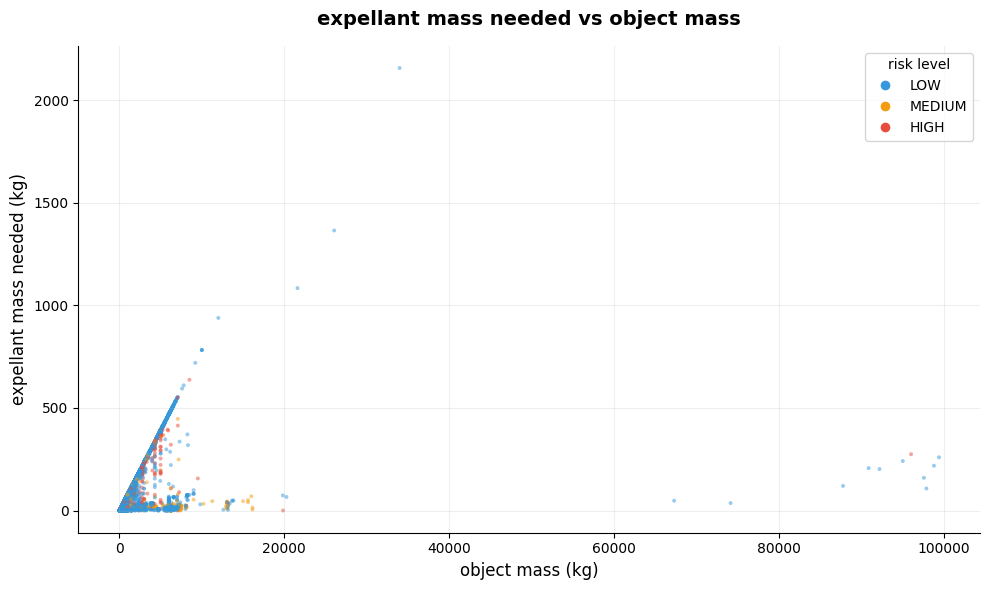

In [11]:
# expellant vs object mass — heavier objects need more expellant obviously
fig, ax = plt.subplots(figsize=(10, 6))

sample = merged[(merged['attr_mass'].between(1, 100000)) & 
                (merged['expellant_mass_kg'].between(0, 5000))].dropna(subset=['expellant_mass_kg', 'attr_mass'])

colors = sample['risk_label'].map({'LOW': '#3498db', 'MEDIUM': '#f39c12', 'HIGH': '#e74c3c'})

ax.scatter(sample['attr_mass'], sample['expellant_mass_kg'],
           c=colors, s=8, alpha=0.5, edgecolors='none')

ax.set_title('expellant mass needed vs object mass', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('object mass (kg)', fontsize=12)
ax.set_ylabel('expellant mass needed (kg)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.2)

from matplotlib.lines import Line2D
legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#3498db', markersize=8, label='LOW'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#f39c12', markersize=8, label='MEDIUM'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=8, label='HIGH'),
]
ax.legend(handles=legend, title='risk level')
plt.tight_layout()
plt.show()

/tmp/ipykernel_12698/3952792143.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  regime_expellant = merged.groupby('regime')['expellant_mass_kg'].median().reindex(['VLEO', 'LEO', 'MEO', 'GEO']).dropna()


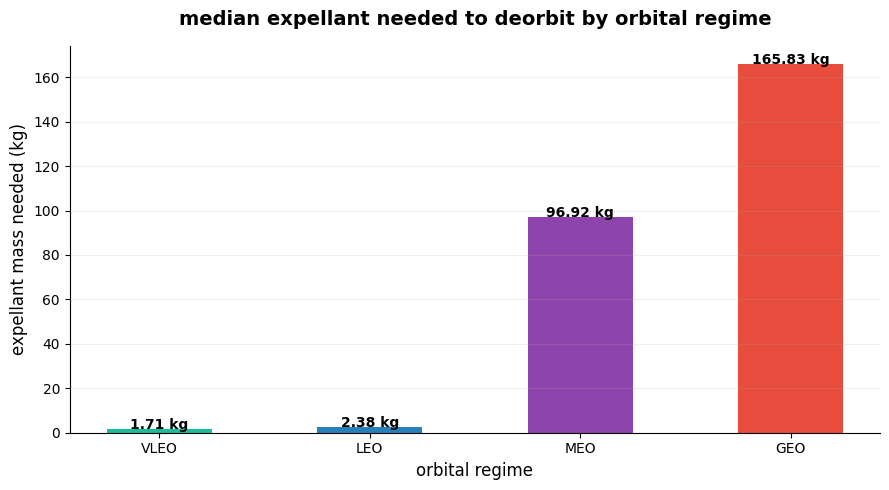

In [12]:
# median expellant needed per regime
fig, ax = plt.subplots(figsize=(9, 5))

regime_expellant = merged.groupby('regime')['expellant_mass_kg'].median().reindex(['VLEO', 'LEO', 'MEO', 'GEO']).dropna()
colors = ['#1abc9c', '#2980b9', '#8e44ad', '#e74c3c']

bars = ax.bar(regime_expellant.index, regime_expellant.values, color=colors, edgecolor='none', width=0.5)

for bar, val in zip(bars, regime_expellant.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{val:.2f} kg', ha='center', fontweight='bold', fontsize=10)

ax.set_title('median expellant needed to deorbit by orbital regime', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('orbital regime', fontsize=12)
ax.set_ylabel('expellant mass needed (kg)', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.show()

In [13]:
# most important — high risk objects and how much expellant to fix them
print("high risk objects and expellant needed:")
merged[merged['risk_label'] == 'HIGH'][['OBJECT_NAME', 'OBJECT_TYPE', 
    'altitude_km', 'attr_mass', 'deltav_km_s', 'expellant_mass_kg']].dropna().sort_values('expellant_mass_kg').head(15)

high risk objects and expellant needed:


,OBJECT_NAME,OBJECT_TYPE,altitude_km,attr_mass,deltav_km_s,expellant_mass_kg
34818,HADES,PAYLOAD,2.893566e+13,0.375,0.0001,0.000
34799,FOSSASAT2E15 (FEROX),PAYLOAD,3.662757e+13,2.000,0.0001,0.000
35455,FEES,PAYLOAD,2.417402e+02,0.300,0.0123,0.000
3941,OBJECT W,UNKNOWN,3.242252e+02,0.250,0.0362,0.000
31004,OBJECT AR,UNKNOWN,6.061377e+11,2.010,0.0008,0.000
31128,ASTROCAST-0301,PAYLOAD,5.225310e+12,4.500,0.0003,0.000
3940,OBJECT AX,UNKNOWN,3.693518e+02,0.125,0.0491,0.000
8365,OBJECT CN,UNKNOWN,2.853325e+02,1.000,0.0250,0.001
4417,PICO-01B009,PAYLOAD,3.879088e+02,0.500,0.0543,0.001
4389,OBJECT BA,UNKNOWN,3.829436e+02,0.250,0.0529,0.001


In [16]:
merged.to_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/merged/ML_merged.parquet", index=False)
print("saved with expellant data!!", merged.shape)

saved with expellant data!! (66666, 59)
